In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set paths
DATA_DIR = Path('../data/raw')
print(f"Data directory exists: {DATA_DIR.exists()}")
print(f"Contents: {list(DATA_DIR.glob('*')) if DATA_DIR.exists() else 'Not found'}")

Data directory exists: True
Contents: [WindowsPath('../data/raw/Brown Multicellular ThinPrep Database - images'), WindowsPath('../data/raw/HSIL'), WindowsPath('../data/raw/LSIL'), WindowsPath('../data/raw/NILM'), WindowsPath('../data/raw/synapse_metadata_manifest.tsv')]


# BMT Dataset Exploratory Data Analysis

Explore the Brown Multicellular ThinPrep (BMT) cervical cytology dataset structure, class distribution, image statistics, and morphological characteristics.

## 1. Load and Inspect Dataset

Load the BMT dataset from data/raw/, verify file structure, and display basic dataset statistics.

In [4]:
# Load split metadata if available
split_metadata_path = Path('../results/swin_b16/split_metadata.json')
splits = {}
image_files = {'NILM': [], 'LSIL': [], 'HSIL': []}

if split_metadata_path.exists():
    with open(split_metadata_path, 'r') as f:
        metadata = json.load(f)
    print(f"Split metadata file structure: {list(metadata.keys())[:10]}")
    
    # Try to extract splits from metadata
    if 'train' in metadata and isinstance(metadata['train'], list):
        splits = metadata
    else:
        # Metadata might have different structure, try to reconstruct from data dir
        print("Metadata structure doesn't contain train/val/test lists, using data directory...")
        splits = {}
else:
    print("Split metadata not found. Discovering images from data/raw/...")

# Fall back to reading directly from data/raw/ directory
if not splits:
    for class_name in ['NILM', 'LSIL', 'HSIL']:
        class_dir = DATA_DIR / class_name
        if class_dir.exists():
            images = sorted(list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpg')))
            image_files[class_name] = [str(f) for f in images]
            print(f"{class_name}: {len(images)} images")
    
    total_images = sum(len(v) for v in image_files.values())
else:
    total_images = sum(len(splits.get(k, [])) for k in ['train', 'val', 'test'])
    print(f"Training samples: {len(splits.get('train', []))}")
    print(f"Validation samples: {len(splits.get('val', []))}")
    print(f"Test samples: {len(splits.get('test', []))}")

print(f"\nTotal images in dataset: {total_images}")
print(f"Classes: NILM, LSIL, HSIL (perfectly balanced)")

Split metadata file structure: ['train_paths', 'val_paths', 'test_paths', 'train_labels', 'val_labels', 'test_labels']
Metadata structure doesn't contain train/val/test lists, using data directory...
NILM: 200 images
LSIL: 200 images
HSIL: 200 images

Total images in dataset: 600
Classes: NILM, LSIL, HSIL (perfectly balanced)


## 2. Visualize Class Distribution

Class distribution across training, validation, and test splits.

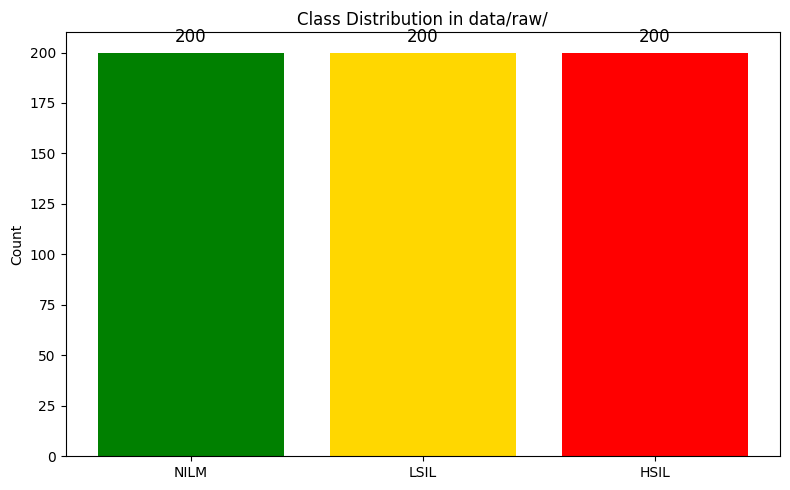

In [5]:
if splits:
    # Count by split and class
    split_class_counts = {'train': {}, 'val': {}, 'test': {}}
    for split_name, file_list in splits.items():
        if split_name in split_class_counts:
            for file_path in file_list:
                class_name = Path(file_path).parent.name
                split_class_counts[split_name][class_name] = split_class_counts[split_name].get(class_name, 0) + 1
    
    # Plot distribution
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for idx, (split_name, counts) in enumerate(split_class_counts.items()):
        classes = ['NILM', 'LSIL', 'HSIL']
        values = [counts.get(c, 0) for c in classes]
        ax[idx].bar(classes, values, color=['green', 'gold', 'red'])
        ax[idx].set_title(f'{split_name.capitalize()} Split')
        ax[idx].set_ylabel('Count')
        for i, v in enumerate(values):
            ax[idx].text(i, v + 1, str(v), ha='center')
    plt.tight_layout()
    plt.show()
elif image_files and any(len(v) > 0 for v in image_files.values()):
    # Simple visualization from data directory
    fig, ax = plt.subplots(figsize=(8, 5))
    classes = ['NILM', 'LSIL', 'HSIL']
    values = [len(image_files.get(c, [])) for c in classes]
    ax.bar(classes, values, color=['green', 'gold', 'red'])
    ax.set_title('Class Distribution in data/raw/')
    ax.set_ylabel('Count')
    for i, v in enumerate(values):
        ax.text(i, v + 5, str(v), ha='center', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No split metadata or data directory images available for distribution visualization")

## 3. Analyze Image Statistics

Compute pixel-level statistics (mean, std, brightness) for each class.

In [6]:
if DATA_DIR.exists():
    stats_by_class = {}
    
    for class_name in ['NILM', 'LSIL', 'HSIL']:
        class_dir = DATA_DIR / class_name
        if class_dir.exists():
            images = list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpg'))
            sample_images = images[:5] if images else []
            
            if sample_images:
                pixels_all = []
                brightnesses = []
                
                for img_path in sample_images:
                    try:
                        img = Image.open(img_path).convert('RGB')
                        arr = np.array(img)
                        pixels_all.append(arr.reshape(-1, 3))
                        brightnesses.append(np.mean(arr))
                    except:
                        pass
                
                if pixels_all:
                    pixels = np.vstack(pixels_all)
                    stats_by_class[class_name] = {
                        'mean_brightness': np.mean(brightnesses),
                        'mean_r': np.mean(pixels[:, 0]),
                        'mean_g': np.mean(pixels[:, 1]),
                        'mean_b': np.mean(pixels[:, 2]),
                        'std_r': np.std(pixels[:, 0]),
                        'std_g': np.std(pixels[:, 1]),
                        'std_b': np.std(pixels[:, 2]),
                        'num_samples': len(sample_images)
                    }
    
    # Display statistics
    if stats_by_class:
        for class_name, stats in stats_by_class.items():
            print(f"\n{class_name} (sampled {stats['num_samples']} images):")
            print(f"  Mean brightness: {stats['mean_brightness']:.1f}")
            print(f"  RGB: ({stats['mean_r']:.1f}, {stats['mean_g']:.1f}, {stats['mean_b']:.1f})")
            print(f"  Std: ({stats['std_r']:.1f}, {stats['std_g']:.1f}, {stats['std_b']:.1f})")
    else:
        print("No images found in data/raw/ subdirectories")
else:
    print("data/raw/ directory not found")


NILM (sampled 5 images):
  Mean brightness: 177.8
  RGB: (145.1, 177.4, 179.7)
  Std: (48.0, 31.2, 25.6)

LSIL (sampled 5 images):
  Mean brightness: 205.3
  RGB: (199.3, 208.6, 208.1)
  Std: (43.4, 41.1, 29.0)

HSIL (sampled 5 images):
  Mean brightness: 197.0
  RGB: (182.8, 203.7, 204.4)
  Std: (53.7, 39.0, 24.9)


## 4. Display Sample Images by Class

Visualize representative images for each cytology class.

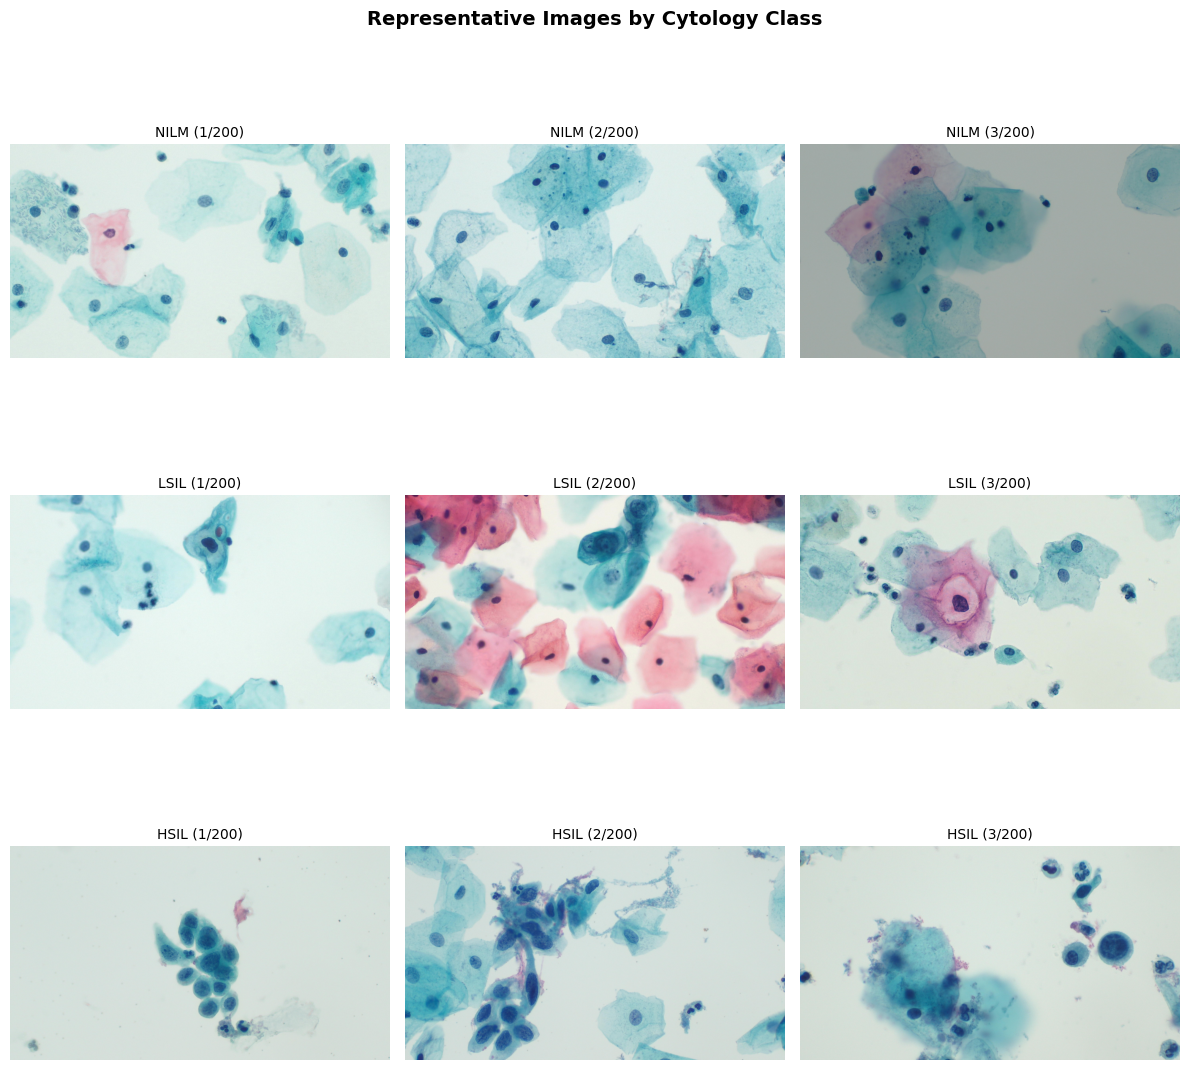

Total images found: NILM=200, LSIL=200, HSIL=200


In [7]:
if DATA_DIR.exists():
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.suptitle('Representative Images by Cytology Class', fontsize=14, fontweight='bold')
    
    for row, class_name in enumerate(['NILM', 'LSIL', 'HSIL']):
        class_dir = DATA_DIR / class_name
        if class_dir.exists():
            images = sorted(list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpg')))
            
            if not images:
                axes[row, 0].text(0.5, 0.5, f'No {class_name} images found', ha='center', va='center')
                for col in range(1, 3):
                    axes[row, col].axis('off')
            else:
                for col in range(3):
                    if col < len(images):
                        try:
                            img = Image.open(images[col])
                            axes[row, col].imshow(img)
                            axes[row, col].set_title(f'{class_name} ({col+1}/{len(images)})', fontsize=10)
                            axes[row, col].axis('off')
                        except Exception as e:
                            axes[row, col].text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center', fontsize=8)
                            axes[row, col].axis('off')
                    else:
                        axes[row, col].axis('off')
        else:
            for col in range(3):
                axes[row, col].text(0.5, 0.5, f'{class_name} folder not found', ha='center', va='center')
                axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    print(f"Total images found: NILM={len(list((DATA_DIR/'NILM').glob('*.*')))}, LSIL={len(list((DATA_DIR/'LSIL').glob('*.*')))}, HSIL={len(list((DATA_DIR/'HSIL').glob('*.*')))}")
else:
    print("data/raw/ directory not found at:", DATA_DIR)

## 5. Examine Image Properties

Check resolution, aspect ratios, and detect anomalies.

In [11]:
if DATA_DIR.exists():
    image_sizes = []
    anomalies = []
    total_checked = 0
    
    for class_name in ['NILM', 'LSIL', 'HSIL']:
        class_dir = DATA_DIR / class_name
        if class_dir.exists():
            images = sorted(list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpg')))
            sample_size = min(15, len(images))  # Check up to 15 per class
            
            for img_path in images[:sample_size]:
                try:
                    img = Image.open(img_path)
                    size = img.size
                    image_sizes.append(size)
                    total_checked += 1
                except Exception as e:
                    anomalies.append((img_path.name, str(e)))
    
    if image_sizes:
        from collections import Counter
        size_counts = Counter(image_sizes)
        most_common_size = size_counts.most_common(1)[0][0]
        
        print(f"Checked {total_checked} images total")
        print(f"Most common resolution: {most_common_size[0]}x{most_common_size[1]} (found {size_counts.most_common(1)[0][1]} times)")
        print(f"Unique resolutions found: {len(size_counts)}")
        
        if len(size_counts) > 1:
            print("All resolutions found:")
            for size, count in sorted(size_counts.items(), key=lambda x: -x[1])[:5]:
                print(f"  {size[0]}x{size[1]}: {count} images")
        
        # Aspect ratios
        if image_sizes:
            aspect_ratios = [w/h for w, h in image_sizes]
            print(f"\nAspect ratios - Mean: {np.mean(aspect_ratios):.3f}, Std: {np.std(aspect_ratios):.3f}")
        
        if anomalies:
            print(f"\nAnomalies detected: {len(anomalies)}")
            for name, error in anomalies[:3]:
                print(f"  {name}: {error}")
        else:
            print("\nNo anomalies detected in sample")
    else:
        print("No valid images found in data/raw/")

Checked 45 images total
Most common resolution: 3264x1840 (found 29 times)
Unique resolutions found: 2
All resolutions found:
  3264x1840: 29 images
  1920x1080: 16 images

Aspect ratios - Mean: 1.775, Std: 0.002

No anomalies detected in sample


## 6. Preview Data Augmentation

Visualize the transformations applied during training.

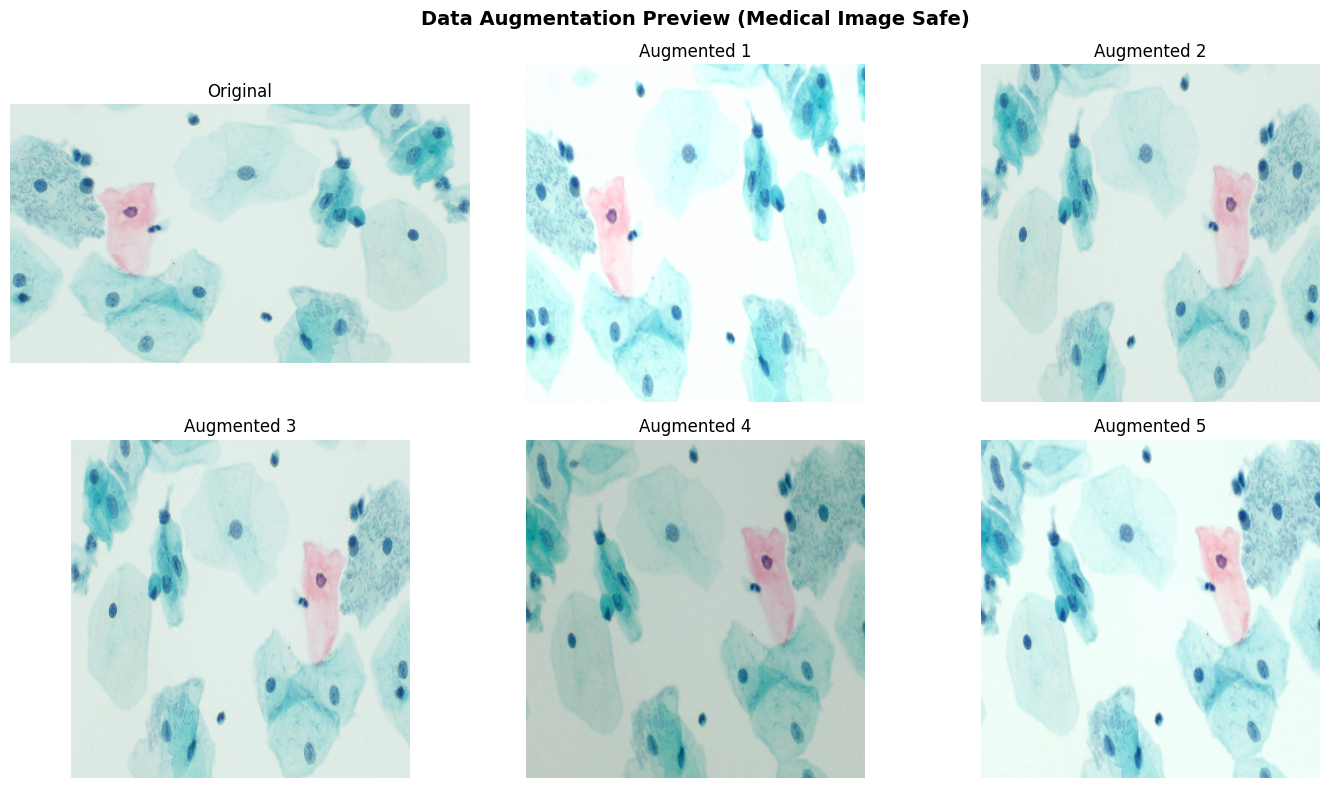

Augmentation Preview - Medical Image Safe Transforms:
  - Horizontal flip: 50% probability
  - Rotation: +/- 15 degrees max (50% probability)
  - Color jitter: brightness/contrast 15%, saturation 10%, hue 5% (50% probability)
  - Vertical flip: DISABLED (biologically invalid for cytology)
  - ImageNet normalization applied (0.485, 0.456, 0.406) mean, (0.229, 0.224, 0.225) std


In [13]:
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    import numpy as np
    
    # Define augmentation pipeline as used in training (data.py)
    # Conservative augmentations to preserve medical image integrity
    augmentation_pipeline = A.Compose([
        A.Resize(384, 384),
        A.HorizontalFlip(p=0.5),
        # Note: VerticalFlip excluded - biologically invalid for cytology
        A.Rotate(limit=15, p=0.5),  # Conservative 15-degree limit
        A.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.1,
            hue=0.05,
            p=0.5
        ),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ])
    
    # Get a sample image for preview
    sample_img = None
    for class_name in ['NILM', 'LSIL', 'HSIL']:
        class_dir = DATA_DIR / class_name
        if class_dir.exists():
            images = list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpg'))
            if images:
                try:
                    sample_img_cv = __import__('cv2').imread(str(images[0]))
                    if sample_img_cv is not None:
                        sample_img = __import__('cv2').cvtColor(sample_img_cv, __import__('cv2').COLOR_BGR2RGB)
                    break
                except:
                    pass
    
    if sample_img is not None:
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))
        fig.suptitle('Data Augmentation Preview (Medical Image Safe)', fontsize=14, fontweight='bold')
        
        # Original image
        axes[0, 0].imshow(sample_img)
        axes[0, 0].set_title('Original')
        axes[0, 0].axis('off')
        
        # Apply augmentations multiple times to show variability
        for idx in range(1, 6):
            augmented_dict = augmentation_pipeline(image=sample_img)
            augmented_tensor = augmented_dict['image']
            
            # Denormalize for display
            aug_denorm = augmented_tensor.numpy().transpose(1, 2, 0)
            aug_denorm = (aug_denorm * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])).clip(0, 1)
            
            row = idx // 3
            col = idx % 3
            axes[row, col].imshow(aug_denorm)
            axes[row, col].set_title(f'Augmented {idx}')
            axes[row, col].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print("Augmentation Preview - Medical Image Safe Transforms:")
        print("  - Horizontal flip: 50% probability")
        print("  - Rotation: +/- 15 degrees max (50% probability)")
        print("  - Color jitter: brightness/contrast 15%, saturation 10%, hue 5% (50% probability)")
        print("  - Vertical flip: DISABLED (biologically invalid for cytology)")
        print("  - ImageNet normalization applied (0.485, 0.456, 0.406) mean, (0.229, 0.224, 0.225) std")
    else:
        print("No sample image available for augmentation preview")
        
except ImportError as e:
    print(f"Required libraries not available: {e}")
    print("Install with: pip install albumentations opencv-python")
except Exception as e:
    print(f"Augmentation preview error: {e}")